# Geração de Movimento com Kimodo + Constraints

Este notebook demonstra como gerar uma pose com o **Kimodo** usando constraints mockup,
a partir de um prompt descritivo real gerado pelo Qwen3-VL no pipeline RobotEmotions.

**Prompt de referência:** `robot_emotions_10ms_u02_tag11__w000`
- Emoção: Happiness / Autobiographical recall
- Descrição Qwen: *"A person stands still, hands clasped together, head slightly tilted, arms moving subtly, legs stationary"*

**Constraints usados neste notebook:**
1. `root2d` — Sparse waypoints: a pessoa permanece praticamente no mesmo lugar (modo standing still)
2. `right-hand` — Posição da mão direita fixada em frame chave (mãos entrelaçadas perto do peito)

Os constraints são **mockup** — valores razoáveis construídos manualmente conforme a documentação do Kimodo,
sem derivação automática do pose3d real.

## Ambiente
Executar no conda env `kimodo`:
```bash
conda activate kimodo
jupyter notebook kimodo_constraints_example.ipynb
```

## 1. Configuração

In [6]:
import json
import os
import subprocess
from pathlib import Path

import numpy as np

# Prompt do Qwen3-VL para a janela robot_emotions_10ms_u02_tag11__w000
PROMPT_TEXT = "A person stands still, hands clasped together, head slightly tilted, arms moving subtly, legs stationary"

# Duração da janela original: 5 segundos a 30 fps = 150 frames
DURATION_SEC = 5.0
FPS = 30
N_FRAMES = int(DURATION_SEC * FPS)  # 150

# SMPL-X skeleton (22 joints). Export: motion_amass.npz (formato AMASS)
MODEL = "Kimodo-SMPLX-RP-v1"

OUTPUT_DIR = Path("output/kimodo_constraints_example")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONSTRAINTS_PATH = OUTPUT_DIR / "constraints.json"
OUTPUT_STEM = str(OUTPUT_DIR / "motion")

print(f"Prompt: {PROMPT_TEXT}")
print(f"Duração: {DURATION_SEC}s | FPS: {FPS} | Frames: {N_FRAMES}")
print(f"Modelo: {MODEL}")
print(f"Output: {OUTPUT_DIR}")

Prompt: A person stands still, hands clasped together, head slightly tilted, arms moving subtly, legs stationary
Duração: 5.0s | FPS: 30 | Frames: 150
Modelo: Kimodo-SMPLX-RP-v1
Output: output/kimodo_constraints_example


## 2. Definição dos Constraints (Mockup)

Seguindo o formato JSON do Kimodo (`kimodo/docs/source/user_guide/constraints.md`).

### Constraint 1 — `root2d`: Sparse waypoints
A pessoa fica parada. Três waypoints no plano do chão `[x, z]` com valor próximo de zero,
ancorados em frames 0, 75 e 149. O Kimodo interpola entre eles.

### Constraint 2 — `right-hand`: Mão direita fixada
As mãos estão entrelaçadas na frente do peito. Fixamos a mão direita em dois frames (0 e 149).

O modelo SMPL-X usa **22 joints** (somente corpo, sem dedos detalhados). Campos obrigatórios:
- `local_joints_rot`: `[T, J=22, 3]` em axis-angle
- `root_positions`: `[T, 3]` — posição da raiz (quadril) em metros

In [7]:
# -------------------------------------------------------------------
# Constraint 1: root2d — sparse waypoints (pessoa parada)
# smooth_root_2d: [x, z] no plano do chão, em metros
# -------------------------------------------------------------------
root2d_constraint = {
    "type": "root2d",
    "frame_indices": [0, 75, 149],
    "smooth_root_2d": [
        [0.0,  0.0],   # frame 0:   posição inicial
        [0.02, 0.01],  # frame 75:  pequena oscilação (breathing / weight shift)
        [0.01, 0.0],   # frame 149: volta próximo à origem
    ]
}

# -------------------------------------------------------------------
# Constraint 2: right-hand — mão direita fixada perto do peito
#
# Kimodo-SMPLX-RP-v1 usa 22 joints (corpo SMPL-X sem mãos detalhadas).
# local_joints_rot shape: [T=2, J=22, 3]  — axis-angle, zeros = identidade
#
# Índices SMPL-X (22 joints):
#   0=Pelvis, 1=L_Hip, 2=R_Hip, 3=Spine1, 4=L_Knee, 5=R_Knee,
#   6=Spine2, 7=L_Ankle, 8=R_Ankle, 9=Spine3, 10=L_Foot, 11=R_Foot,
#   12=Neck, 13=L_Collar, 14=R_Collar, 15=Head,
#   16=L_Shoulder, 17=R_Shoulder, 18=L_Elbow, 19=R_Elbow,
#   20=L_Wrist, 21=R_Wrist
# -------------------------------------------------------------------
J = 22  # SMPL-X body joints
T_keyframes = 2

rots = np.zeros((T_keyframes, J, 3), dtype=np.float64)

# Leve flexão no cotovelo direito (joint 19) para braço na frente do peito
rots[:, 19, :] = [1.5, 0.0, 0.0]  # ~85° de flexão em torno de X

right_hand_constraint = {
    "type": "right-hand",
    "frame_indices": [0, 149],
    "local_joints_rot": rots.tolist(),
    "root_positions": [
        [0.0, 0.95, 0.0],  # frame 0:   quadril na altura padrão
        [0.0, 0.95, 0.0],  # frame 149: mesma altura (pessoa parada)
    ]
}

constraints = [root2d_constraint, right_hand_constraint]

with open(CONSTRAINTS_PATH, "w") as f:
    json.dump(constraints, f, indent=2)

print(f"Constraints salvos em: {CONSTRAINTS_PATH}")
print("\nResumo:")
for c in constraints:
    print(f"  type={c['type']:15s} | frames={c['frame_indices']}")

Constraints salvos em: output/kimodo_constraints_example/constraints.json

Resumo:
  type=root2d          | frames=[0, 75, 149]
  type=right-hand      | frames=[0, 149]


## 3. Geração com Kimodo

Chama `kimodo_gen` via CLI com o prompt e o arquivo de constraints.

In [8]:
env = os.environ.copy()
env["MKL_THREADING_LAYER"] = "GNU"

cmd = [
    "kimodo_gen", PROMPT_TEXT,
    "--model", MODEL,
    "--duration", str(DURATION_SEC),
    "--constraints", str(CONSTRAINTS_PATH),
    "--output", OUTPUT_STEM,
    "--seed", "42",
    "--diffusion_steps", "100",
]

print("Comando:")
print(" ".join(cmd))
print("\nExecutando Kimodo...")

result = subprocess.run(cmd, capture_output=True, text=True, env=env)

print("\n--- stdout ---")
print(result.stdout)
if result.stderr:
    print("\n--- stderr ---")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"kimodo_gen falhou com código {result.returncode}")

print("\nGeração concluída!")

Comando:
kimodo_gen A person stands still, hands clasped together, head slightly tilted, arms moving subtly, legs stationary --model Kimodo-SMPLX-RP-v1 --duration 5.0 --constraints output/kimodo_constraints_example/constraints.json --output output/kimodo_constraints_example/motion --seed 42 --diffusion_steps 100

Executando Kimodo...

--- stdout ---
Using device: cuda:0
Text encoder service is unreachable, falling back to local LLM2Vec encoder. (InstantiationException: Error in call to target 'kimodo.model.text_encoder_api.TextEncoderAPI':
ConnectError('[Errno 111] Connection refused'))
Loaded model: Kimodo-SMPLX-RP-v1 (kimodo-smplx-rp)
Will generate motions with the following prompts
    'A person stands still, hands clasped together, head slightly tilted, arms moving subtly, legs stationary.' with 150 frames
Using 2 set of constraints
Saving the npz output to output/kimodo_constraints_example/motion.npz
Saving the amass output to output/kimodo_constraints_example/motion_amass.npz


-

In [9]:
# Kimodo-SMPLX-RP-v1 gera dois NPZ:
#   motion.npz       — formato interno Kimodo (posed_joints, global_rot_mats, ...)
#   motion_amass.npz — formato AMASS/SMPL-X (trans, root_orient, pose_body, ...)
npz_path = Path(OUTPUT_STEM + ".npz")
amass_path = Path(OUTPUT_STEM + "_amass.npz")

if not npz_path.exists():
    candidates = sorted(OUTPUT_DIR.glob("motion*.npz"))
    for p in candidates:
        if "_amass" not in p.name:
            npz_path = p
        else:
            amass_path = p

print(f"NPZ Kimodo : {npz_path}  (exists={npz_path.exists()})")
print(f"NPZ AMASS  : {amass_path}  (exists={amass_path.exists()})")

data = np.load(npz_path)
print("\nChaves no motion.npz (Kimodo):")
for k in data.files:
    print(f"  {k}: {data[k].shape}")

NPZ Kimodo : output/kimodo_constraints_example/motion.npz  (exists=True)
NPZ AMASS  : output/kimodo_constraints_example/motion_amass.npz  (exists=True)

Chaves no motion.npz (Kimodo):
  local_rot_mats: (150, 22, 3, 3)
  global_rot_mats: (150, 22, 3, 3)
  posed_joints: (150, 22, 3)
  root_positions: (150, 3)
  smooth_root_pos: (150, 3)
  foot_contacts: (150, 4)
  global_root_heading: (150, 2)


## 4. Visualização — Trajetória Root e Constraints

Verificação rápida: posição root gerada vs. waypoints definidos.

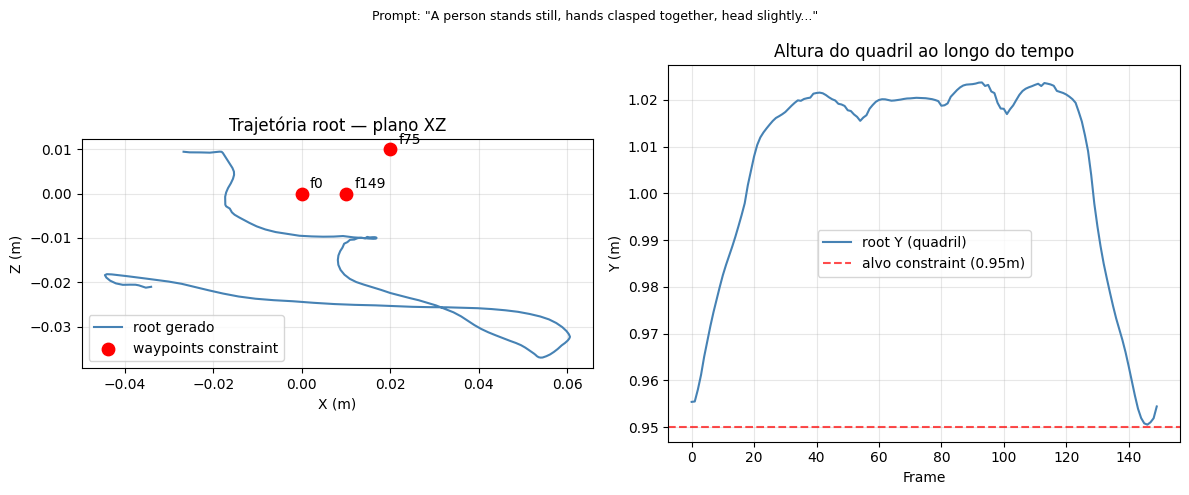

Gráfico salvo.


In [10]:
import matplotlib.pyplot as plt

root_pos = data["root_positions"]  # [T, 3]
smooth_root = data["smooth_root_pos"]  # [T, 3]

# Waypoints do constraint root2d
wp_frames = root2d_constraint["frame_indices"]
wp_xz = np.array(root2d_constraint["smooth_root_2d"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Trajetória XZ (plano do chão)
ax = axes[0]
ax.plot(root_pos[:, 0], root_pos[:, 2], label="root gerado", color="steelblue")
ax.scatter(wp_xz[:, 0], wp_xz[:, 1], color="red", zorder=5, label="waypoints constraint", s=80)
for i, fi in enumerate(wp_frames):
    ax.annotate(f"f{fi}", (wp_xz[i, 0], wp_xz[i, 1]), textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_title("Trajetória root — plano XZ")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Altura Y ao longo do tempo
ax = axes[1]
frames = np.arange(len(root_pos))
ax.plot(frames, root_pos[:, 1], label="root Y (quadril)", color="steelblue")
ax.axhline(0.95, color="red", linestyle="--", alpha=0.7, label="alvo constraint (0.95m)")
ax.set_xlabel("Frame")
ax.set_ylabel("Y (m)")
ax.set_title("Altura do quadril ao longo do tempo")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Prompt: "{PROMPT_TEXT[:60]}..."', fontsize=9)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "trajectory_analysis.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo.")

## 5. Renderização em Vídeo

Usa `posed_joints` do NPZ Kimodo (`motion.npz`) — posições globais dos 22 joints SMPL-X —
para renderizar um vídeo com `matplotlib` 3D, sem necessidade de SMPL-X.

In [12]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import imageio.v2 as imageio
import io

joints = data["posed_joints"]  # [T, J=22, 3]
T_gen, J_gen, _ = joints.shape
print(f"posed_joints: {joints.shape}  (frames={T_gen}, joints={J_gen})")

# Conexões do skeleton SMPL-X (22 joints body):
#   0=Pelvis, 1=L_Hip, 2=R_Hip, 3=Spine1, 4=L_Knee, 5=R_Knee,
#   6=Spine2, 7=L_Ankle, 8=R_Ankle, 9=Spine3, 10=L_Foot, 11=R_Foot,
#   12=Neck, 13=L_Collar, 14=R_Collar, 15=Head,
#   16=L_Shoulder, 17=R_Shoulder, 18=L_Elbow, 19=R_Elbow,
#   20=L_Wrist, 21=R_Wrist
CONNECTIONS = [
    (0, 1), (0, 2),           # pelvis → hips
    (0, 3), (3, 6), (6, 9),   # spine
    (9, 12), (12, 15),         # neck → head
    (9, 13), (13, 16), (16, 18), (18, 20),   # left arm
    (9, 14), (14, 17), (17, 19), (19, 21),   # right arm
    (1, 4), (4, 7), (7, 10),  # left leg
    (2, 5), (5, 8), (8, 11),  # right leg
]

OUT_VIDEO = str(OUTPUT_DIR / "kimodo_constraints_motion.mp4")
VIDEO_FPS = 30

all_xyz = joints.reshape(-1, 3)
cx, cy, cz = all_xyz.mean(axis=0)
span = max(all_xyz.max(axis=0) - all_xyz.min(axis=0)) * 0.6 + 0.5

writer = imageio.get_writer(OUT_VIDEO, fps=VIDEO_FPS)

for t in range(T_gen):
    fig = plt.figure(figsize=(5, 6))
    ax = fig.add_subplot(111, projection="3d")

    j = joints[t]

    ax.scatter(j[:, 0], j[:, 2], j[:, 1], c="steelblue", s=20, depthshade=False)
    for a, b in CONNECTIONS:
        if a < J_gen and b < J_gen:
            ax.plot([j[a, 0], j[b, 0]], [j[a, 2], j[b, 2]], [j[a, 1], j[b, 1]], "k-", lw=1.5)

    ax.set_xlim(cx - span, cx + span)
    ax.set_ylim(cz - span, cz + span)
    ax.set_zlim(0, cy + span)
    ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_zlabel("Y")
    ax.set_title(f"Frame {t}/{T_gen-1}  |  {MODEL}")
    ax.view_init(elev=10, azim=-60)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80, bbox_inches="tight")
    buf.seek(0)
    writer.append_data(imageio.imread(buf))
    plt.close(fig)

    if (t + 1) % 30 == 0 or t == T_gen - 1:
        print(f"Renderizado {t+1}/{T_gen}")

writer.close()
print(f"\nVídeo salvo em: {OUT_VIDEO}")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (338, 342) to (352, 352) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


posed_joints: (150, 22, 3)  (frames=150, joints=22)
Renderizado 30/150
Renderizado 60/150
Renderizado 90/150
Renderizado 120/150
Renderizado 150/150

Vídeo salvo em: output/kimodo_constraints_example/kimodo_constraints_motion.mp4


In [13]:
from IPython.display import Video, display

display(Video(OUT_VIDEO, embed=True, width=500))

## 6. Inspeção dos Constraints

Visualiza o arquivo de constraints gerado para referência.

In [14]:
with open(CONSTRAINTS_PATH) as f:
    raw = json.load(f)

for c in raw:
    print(f"type: {c['type']}")
    print(f"  frame_indices: {c['frame_indices']}")
    if 'smooth_root_2d' in c:
        print(f"  smooth_root_2d: {c['smooth_root_2d']}")
    if 'root_positions' in c:
        print(f"  root_positions: {c['root_positions']}")
    if 'local_joints_rot' in c:
        arr = np.array(c['local_joints_rot'])
        print(f"  local_joints_rot shape: {arr.shape}  (axis-angle, zeros=identidade)")
        nonzero = np.argwhere(arr.any(axis=-1))
        if len(nonzero):
            for fi, ji in nonzero:
                print(f"    frame[{fi}] joint[{ji}] = {arr[fi, ji]}")
    print()

type: root2d
  frame_indices: [0, 75, 149]
  smooth_root_2d: [[0.0, 0.0], [0.02, 0.01], [0.01, 0.0]]

type: right-hand
  frame_indices: [0, 149]
  root_positions: [[0.0, 0.95, 0.0], [0.0, 0.95, 0.0]]
  local_joints_rot shape: (2, 22, 3)  (axis-angle, zeros=identidade)
    frame[0] joint[19] = [1.5 0.  0. ]
    frame[1] joint[19] = [1.5 0.  0. ]



## Referências

- Documentação de constraints: `kimodo/docs/source/user_guide/constraints.md`
- Conceitos de constraints: `kimodo/docs/source/key_concepts/constraints.md`
- Exemplos oficiais: `kimodo/kimodo/assets/demo/examples/kimodo-soma-rp/`
- Skeleton SMPL-X (22 joints): `kimodo/docs/source/key_concepts/skeleton.md`
- Output formats (AMASS NPZ): `kimodo/docs/source/user_guide/output_formats.md`